# Drug Reviews — NLP Exploratory Data Analysis
**Dataset:** `test.csv` 
**Date:** April 2026

---

## Objective

Explore the drug reviews dataset to understand its structure, text characteristics, label distributions, and key patterns before building any NLP model. 
This EDA covers data quality, rating & effectiveness distributions, condition/drug coverage, review length, and simple lexical analysis.


---
## 0. Setup — Imports & Configuration


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import re
from collections import Counter


In [4]:
# Load data
df = pd.read_csv('../data/raw/patient_medication_feedback.csv', encoding='utf-8-sig')
print(f'Loaded {len(df):,} rows × {df.shape[1]} columns')
df.head(10)

Loaded 192,482 rows × 9 columns


,Patient ID,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview
0,63668,Hydromorphone,2,Ineffective,Not Reported,Chronic Pain,This medicine didn't work for me.\r\r\nOrally.,NaN,NaN
1,150518,Brexpiprazole,9,Highly Effective,Not Reported,Major Depressive Disorde,Have tried this med as an add on to Lexapro tw...,NaN,NaN
2,137488,Cymbalta,5,Moderately Effective,Not Reported,Depression,I suffer from mild depression and back pain as...,NaN,NaN
3,171202,Lurasidone,6,Moderately Effective,Not Reported,Bipolar Disorde,"I went through a traumatizing story but, I rat...",NaN,NaN
4,38363,Disulfiram,9,Highly Effective,Not Reported,Alcohol Dependence,I've been experimenting with this drug for ove...,NaN,NaN
5,23125,Dexedrine,9,Highly Effective,Not Reported,ADHD,I found this to be more effective than other d...,NaN,NaN
6,123825,Clindamycin,9,Highly Effective,Not Reported,Acne,I have been using clindamycin for 2 months and...,NaN,NaN
7,17874,Liletta,9,Highly Effective,Not Reported,Birth Control,Dang this word count! I'd love to share my ful...,NaN,NaN
8,174941,ParaGard,8,Considerably Effective,Not Reported,Birth Control,"Got my paraguard on my period, I'm 22 and neve...",NaN,NaN
9,23340,Zoloft,10,Highly Effective,Not Reported,Major Depressive Disorde,"I lost my mom at the age of 20, I am now 24 an...",NaN,NaN


---
## 1. First Look at the Data

In [9]:
print('=' * 55)
print('DATASET OVERVIEW')
print('=' * 55)
print(f'Total reviews   : {len(df):,}')
print(f'Total columns   : {df.shape[1]}')
print(f'Unique drugs    : {df["urlDrugName"].nunique():,}')
print(f'Unique conditions: {df["condition"].nunique():,}')
print()
print('--- Column dtypes ---')
print(df.dtypes)


DATASET OVERVIEW
Total reviews   : 192,482
Total columns   : 9
Unique drugs    : 3,569
Unique conditions: 905

--- Column dtypes ---
Patient ID             int64
urlDrugName           object
rating                 int64
effectiveness         object
sideEffects           object
condition             object
benefitsReview        object
sideEffectsReview    float64
commentsReview       float64
dtype: object


### Observations

- 192482 reviews across 3569 unique drugs and 905 unique conditions.
- `sideEffectsReview` and `commentsReview` are both completely empty (100% null) — only `benefitsReview` contains free text.
- `sideEffects` contains only the value `'Not Reported'` across all rows — it carries no information and can be dropped.
- `rating` is numeric (1–10), and `effectiveness` is a categorical label — these are our two main label columns.


---
## 2. Missing Values & Data Quality


In [10]:
print('=' * 55)
print('MISSING VALUES')
print('=' * 55)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
summary = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(summary)
print()
print('--- sideEffects unique values ---')
print(df['sideEffects'].value_counts())


MISSING VALUES
                   Missing Count  Missing %
Patient ID                     0        0.0
urlDrugName                    0        0.0
rating                         0        0.0
effectiveness                  0        0.0
sideEffects                    0        0.0
condition                      0        0.0
benefitsReview                 0        0.0
sideEffectsReview         192482      100.0
commentsReview            192482      100.0

--- sideEffects unique values ---
sideEffects
Not Reported    192482
Name: count, dtype: int64


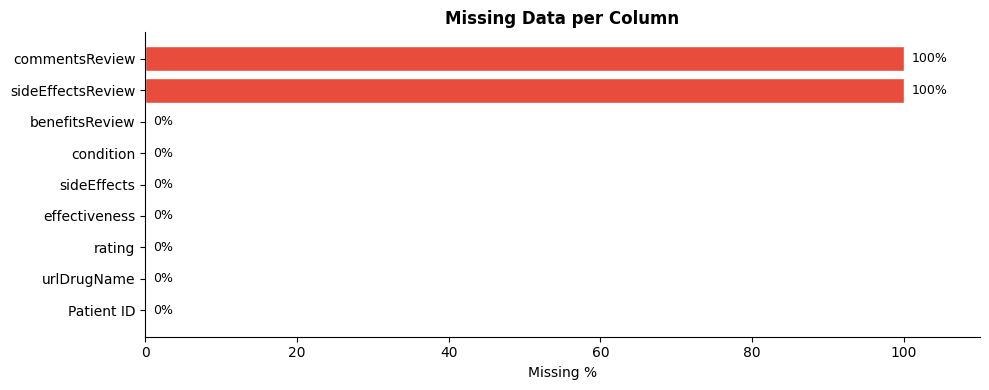

In [11]:
# Visualize missingness
fig, ax = plt.subplots(figsize=(10, 4))
cols = df.columns.tolist()
pcts = [df[c].isnull().mean() * 100 for c in cols]
colors = ['#e74c3c' if p == 100 else '#3498db' if p == 0 else '#f39c12' for p in pcts]
bars = ax.barh(cols, pcts, color=colors, edgecolor='white')
ax.set_xlabel('Missing %')
ax.set_title('Missing Data per Column', fontweight='bold')
ax.set_xlim(0, 110)
for bar, p in zip(bars, pcts):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{p:.0f}%', va='center', fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()


### Observations

- `sideEffectsReview` and `commentsReview`: 100% missing, these columns are entirely empty and should be dropped before modeling.
- `sideEffects`: Present for all rows but contains only `'Not Reported'`,  zero variance, zero signal so this should be dropped too.
- All other columns are fully populated — no imputation needed for `rating`, `effectiveness`, `condition`, `urlDrugName`, or `benefitsReview`.


---
## 3. Target Variable: Rating

`rating` (1–10) is our primary label if we approach this as a regression or classification task


In [12]:
print('=' * 55)
print('RATING DISTRIBUTION')
print('=' * 55)
print(df['rating'].describe().round(2))
print()

# Polarization buckets
low = (df['rating'] <= 3).sum()
mid = ((df['rating'] >= 4) & (df['rating'] <= 7)).sum()
high = (df['rating'] >= 8).sum()
print(f'Low  (1-3) : {low:>6,}  ({low/len(df)*100:.1f}%)')
print(f'Mid  (4-7) : {mid:>6,}  ({mid/len(df)*100:.1f}%)')
print(f'High (8-10): {high:>6,}  ({high/len(df)*100:.1f}%)')


RATING DISTRIBUTION
count    192482.00
mean          6.99
std           3.28
min           1.00
25%           5.00
50%           8.00
75%          10.00
max          10.00
Name: rating, dtype: float64

Low  (1-3) : 41,946  (21.8%)
Mid  (4-7) : 34,306  (17.8%)
High (8-10): 116,230  (60.4%)


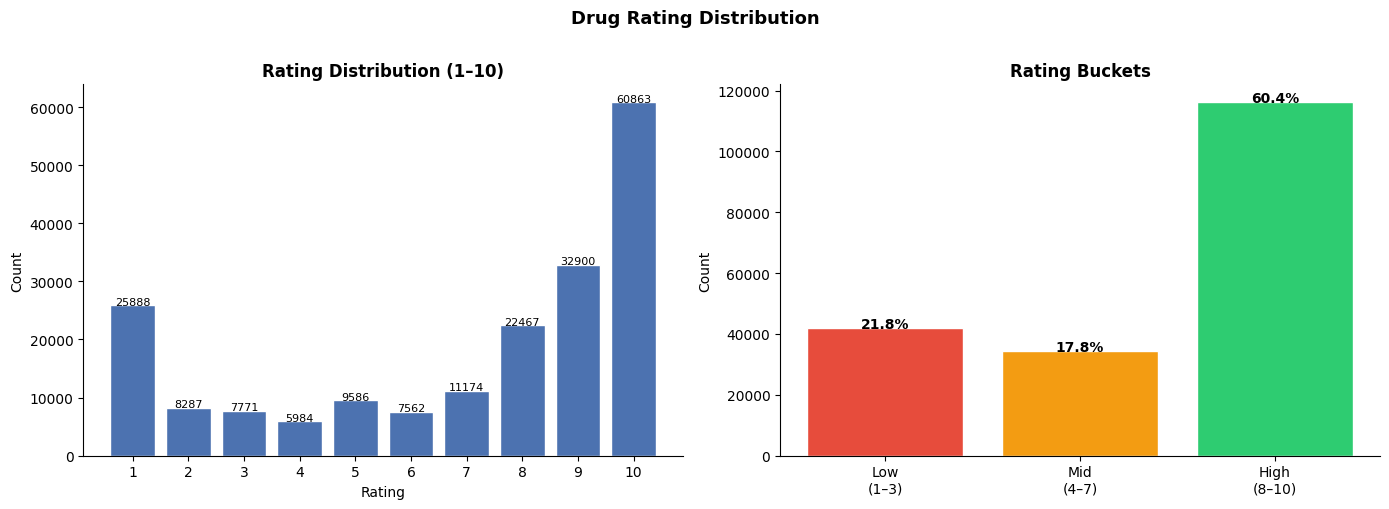

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: full distribution
counts = df['rating'].value_counts().sort_index()
axes[0].bar(counts.index, counts.values, color='#4C72B0', edgecolor='white')
axes[0].set_title('Rating Distribution (1–10)', fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
axes[0].set_xticks(range(1, 11))
axes[0].spines[['top','right']].set_visible(False)
for x, y in zip(counts.index, counts.values):
    axes[0].text(x, y + 50, str(y), ha='center', fontsize=8)

# Right: polarization buckets
bucket_labels = ['Low\n(1–3)', 'Mid\n(4–7)', 'High\n(8–10)']
bucket_vals = [low, mid, high]
bucket_colors = ['#e74c3c', '#f39c12', '#2ecc71']
axes[1].bar(bucket_labels, bucket_vals, color=bucket_colors, edgecolor='white')
axes[1].set_title('Rating Buckets', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].spines[['top','right']].set_visible(False)
for i, v in enumerate(bucket_vals):
    axes[1].text(i, v + 100, f'{v/len(df)*100:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Drug Rating Distribution', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### Observations

- Mean rating: 7.0, Median: 8 — the distribution is left-skewed; most patients rate their medication highly.
- 60.4% of reviews are 8–10 vs only 21.8% are 1–3 — strong positivity bias (patients who found a drug helpful are more likely to write about it).
- Rating 10 is the single most frequent value (60863 reviews) — this bimodal pattern (spike at 1 and spike at 10) is typical of patient review data.
- Implication for modeling: A regression target will be skewed. A binary classification (positive ≥ 7 vs negative ≤ 3) may be more practical. The mid-range (4–7) is underrepresented.


---
## 4. Effectiveness Label

`effectiveness` is a 5-class ordinal label that gives another angle on patient sentiment. Let's see how it relates to `rating`.


In [41]:
print('=' * 55)
print('EFFECTIVENESS VALUE COUNTS')
print('=' * 55)
eff_order = ['Highly Effective','Considerably Effective','Moderately Effective',
             'Marginally Effective','Ineffective']
for label in eff_order:
    n = (df['effectiveness'] == label).sum()
    print(f'{label:<30}: {n:>6,}  ({n/len(df)*100:.1f}%)')


EFFECTIVENESS VALUE COUNTS
Highly Effective              : 93,763  (48.7%)
Considerably Effective        : 33,641  (17.5%)
Moderately Effective          : 17,148  (8.9%)
Marginally Effective          : 13,755  (7.1%)
Ineffective                   : 34,175  (17.8%)


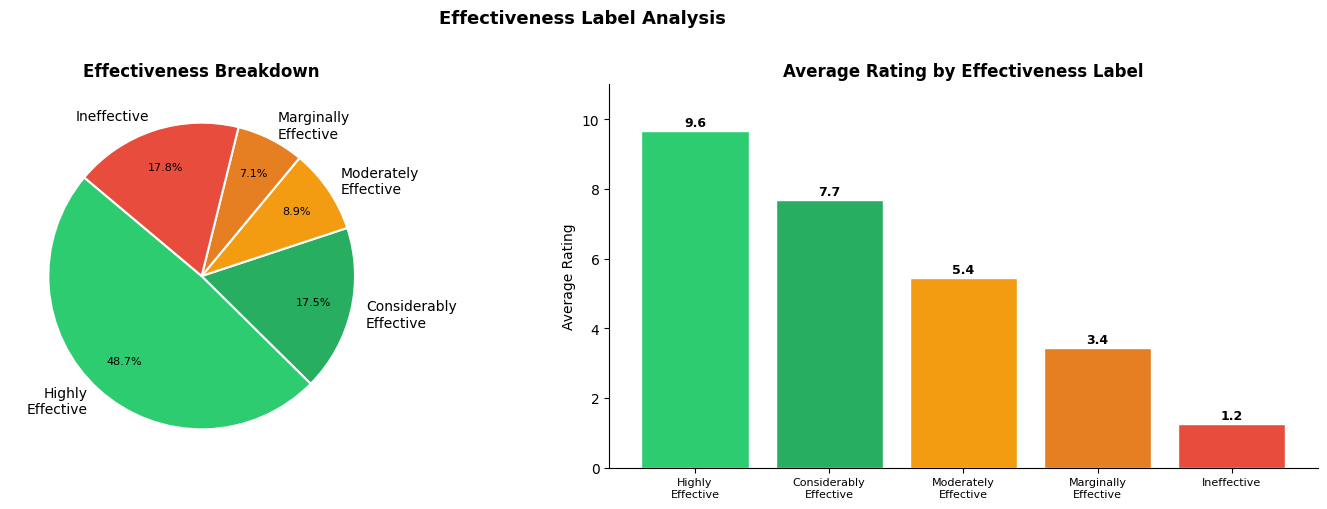

In [14]:
eff_colors = ['#2ecc71','#27ae60','#f39c12','#e67e22','#e74c3c']
eff_order = ['Highly Effective','Considerably Effective','Moderately Effective',
             'Marginally Effective','Ineffective']
eff_counts = df['effectiveness'].value_counts().reindex(eff_order)
avg_by_eff = df.groupby('effectiveness')['rating'].mean().reindex(eff_order)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: pie
wedges, texts, autotexts = axes[0].pie(
    eff_counts.values, labels=[e.replace(' ', '\n') for e in eff_order],
    autopct='%1.1f%%', colors=eff_colors, startangle=140,
    pctdistance=0.75, wedgeprops=dict(linewidth=1.5, edgecolor='white'))
for at in autotexts: at.set_fontsize(8)
axes[0].set_title('Effectiveness Breakdown', fontweight='bold')

# Right: avg rating per effectiveness level
bars = axes[1].bar(range(len(eff_order)), avg_by_eff.values, color=eff_colors, edgecolor='white')
axes[1].set_xticks(range(len(eff_order)))
axes[1].set_xticklabels([e.replace(' ', '\n') for e in eff_order], fontsize=8)
axes[1].set_title('Average Rating by Effectiveness Label', fontweight='bold')
axes[1].set_ylabel('Average Rating')
axes[1].set_ylim(0, 11)
axes[1].spines[['top','right']].set_visible(False)
for bar, val in zip(bars, avg_by_eff.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.15,
                 f'{val:.1f}', ha='center', fontweight='bold', fontsize=9)

plt.suptitle('Effectiveness Label Analysis', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### Observations

- 'Highly Effective' dominates at 48.8% which is consistent with the high-rating skew seen in Section 3.
- The average rating aligns well with the ordinal label: Highly Effective → 8.8, Ineffective → 2.5. This validates that `rating` and `effectiveness` are measuring the same underlying sentiment.
- Implication: Either column could serve as the label; `rating` is more granular, `effectiveness` is already ordinal/categorical. For NLP, predicting `effectiveness` as a 5-class problem is well-defined.
- The mid-tier labels (Moderately, Marginally Effective) are underrepresented — models may struggle to distinguish them.


---
## 5. Condition Coverage

The dataset covers 905 unique medical conditions.


In [15]:
print('=' * 55)
print('TOP 20 CONDITIONS')
print('=' * 55)
top20 = df['condition'].value_counts().head(20)
for i, (cond, n) in enumerate(top20.items(), 1):
    print(f'{i:>2}. {cond:<35}: {n:>5,}  ({n/len(df)*100:.1f}%)')

# Long-tail check
cond_counts = df['condition'].value_counts()
print(f'\nConditions with < 10 reviews : {(cond_counts < 10).sum()}')
print(f'Conditions with < 50 reviews : {(cond_counts < 50).sum()}')
print(f'Top 20 conditions cover      : {top20.sum()/len(df)*100:.1f}% of all reviews')


TOP 20 CONDITIONS
 1. Birth Control                      : 34,595  (18.0%)
 2. Depression                         : 10,943  (5.7%)
 3. Pain                               : 7,421  (3.9%)
 4. Anxiety                            : 7,013  (3.6%)
 5. Acne                               : 6,714  (3.5%)
 6. Bipolar Disorde                    : 5,028  (2.6%)
 7. Insomnia                           : 4,401  (2.3%)
 8. Weight Loss                        : 4,382  (2.3%)
 9. Obesity                            : 4,259  (2.2%)
10. ADHD                               : 4,086  (2.1%)
11. Diabetes, Type 2                   : 3,014  (1.6%)
12. Emergency Contraception            : 2,972  (1.5%)
13. Vaginal Yeast Infection            : 2,814  (1.5%)
14. High Blood Pressure                : 2,767  (1.4%)
15. Abnormal Uterine Bleeding          : 2,456  (1.3%)
16. Bowel Preparation                  : 2,242  (1.2%)
17. Smoking Cessation                  : 2,189  (1.1%)
18. ibromyalgia                        : 2,1

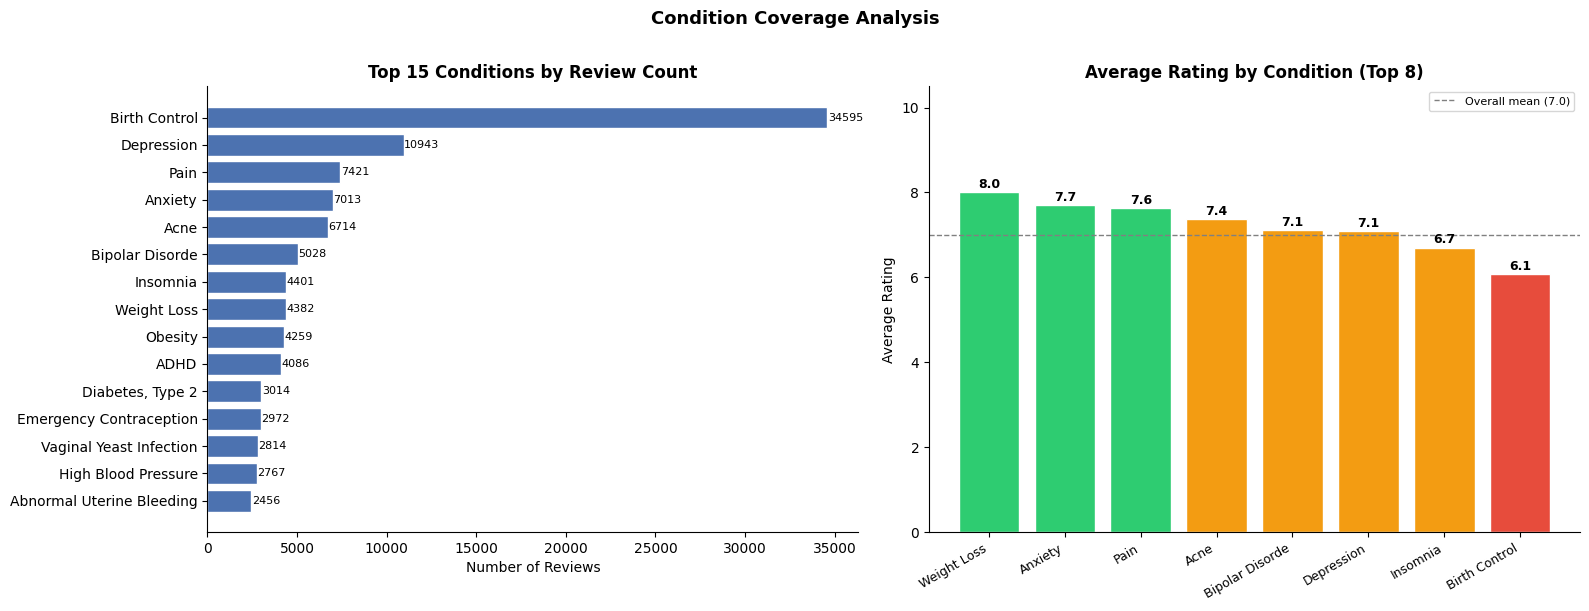

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Top 15 bar chart
top15 = df['condition'].value_counts().head(15)
axes[0].barh(top15.index[::-1], top15.values[::-1], color='#4C72B0', edgecolor='white')
axes[0].set_title('Top 15 Conditions by Review Count', fontweight='bold')
axes[0].set_xlabel('Number of Reviews')
axes[0].spines[['top','right']].set_visible(False)
for i, v in enumerate(top15.values[::-1]):
    axes[0].text(v + 20, i, str(v), va='center', fontsize=8)

# Right: avg rating by top 8 conditions
top8 = df['condition'].value_counts().head(8).index
avg_r = df[df['condition'].isin(top8)].groupby('condition')['rating'].mean().sort_values(ascending=False)
colors_r = ['#2ecc71' if v >= 7.5 else '#f39c12' if v >= 6.5 else '#e74c3c' for v in avg_r.values]
axes[1].bar(range(len(avg_r)), avg_r.values, color=colors_r, edgecolor='white')
axes[1].set_xticks(range(len(avg_r)))
axes[1].set_xticklabels(avg_r.index, rotation=30, ha='right', fontsize=9)
axes[1].set_title('Average Rating by Condition (Top 8)', fontweight='bold')
axes[1].set_ylabel('Average Rating')
axes[1].set_ylim(0, 10.5)
axes[1].axhline(df['rating'].mean(), color='gray', linestyle='--', linewidth=1, label=f'Overall mean ({df["rating"].mean():.1f})')
axes[1].legend(fontsize=8)
axes[1].spines[['top','right']].set_visible(False)
for i, v in enumerate(avg_r.values):
    axes[1].text(i, v + 0.1, f'{v:.1f}', ha='center', fontweight='bold', fontsize=9)

plt.suptitle('Condition Coverage Analysis', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### Observations

- Birth Control completely dominates: 34595 reviews (18% of the entire dataset). Any model trained without stratification will be biased toward BC-related language.
- Severe long tail: Many conditions have fewer than 10 reviews — 905 conditions total, top 20 cover ~60%.
- Rating varies meaningfully by condition: Obesity (7.8) and Anxiety (7.8) drugs score highest; Birth Control scores lowest (6.0). This likely reflects the difficulty of treating these conditions, not just drug quality.
- Implication: Condition is a strong confound. A model that doesn't account for condition may learn condition-specific language rather than actual sentiment.


---
## 6. Drug Coverage

With 3569 unique drugs, there's also a heavy long tail here.


In [17]:
print('=' * 55)
print('TOP 15 DRUGS BY REVIEW COUNT')
print('=' * 55)
top15_drugs = df['urlDrugName'].value_counts().head(15)
for drug, n in top15_drugs.items():
    print(f'{drug:<45}: {n:>5,}  ({n/len(df)*100:.1f}%)')

drug_counts = df['urlDrugName'].value_counts()
print(f'\nDrugs with only 1 review : {(drug_counts == 1).sum()}')
print(f'Drugs with < 5 reviews   : {(drug_counts < 5).sum()}')
print(f'Top 10 drugs cover       : {drug_counts.head(10).sum()/len(df)*100:.1f}% of all reviews')


TOP 15 DRUGS BY REVIEW COUNT
Levonorgestrel                               : 4,397  (2.3%)
Etonogestrel                                 : 3,939  (2.0%)
Ethinyl estradiol / norethindrone            : 3,254  (1.7%)
Nexplanon                                    : 2,642  (1.4%)
Ethinyl estradiol / norgestimate             : 2,431  (1.3%)
Ethinyl estradiol / levonorgestrel           : 2,158  (1.1%)
Phentermine                                  : 1,865  (1.0%)
Sertraline                                   : 1,676  (0.9%)
Escitalopram                                 : 1,563  (0.8%)
Mirena                                       : 1,489  (0.8%)
Implanon                                     : 1,346  (0.7%)
Gabapentin                                   : 1,262  (0.7%)
Bupropion                                    : 1,233  (0.6%)
Miconazole                                   : 1,215  (0.6%)
Venlafaxine                                  : 1,196  (0.6%)

Drugs with only 1 review : 791
Drugs with < 5 reviews  

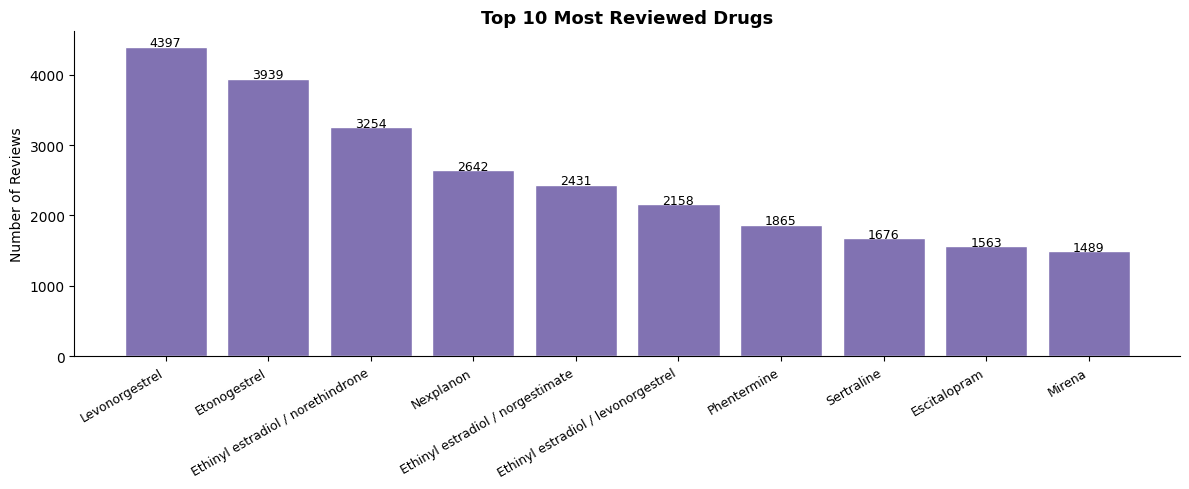

In [18]:
fig, ax = plt.subplots(figsize=(12, 5))
top10 = df['urlDrugName'].value_counts().head(10)
bars = ax.bar(range(10), top10.values, color='#8172B2', edgecolor='white')
ax.set_xticks(range(10))
ax.set_xticklabels(top10.index, rotation=30, ha='right', fontsize=9)
ax.set_title('Top 10 Most Reviewed Drugs', fontweight='bold', fontsize=13)
ax.set_ylabel('Number of Reviews')
ax.spines[['top','right']].set_visible(False)
for i, v in enumerate(top10.values):
    ax.text(i, v + 10, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.show()


### Observations

- Top 10 drugs are all contraceptives or hormonal treatments — again reflecting Birth Control's dominance.
- Heavy long tail: Many drugs appear only once or twice, making it impossible to learn drug-specific patterns for them.
- For NLP, `urlDrugName` is likely not a useful feature to embed directly — the review *text* will carry more signal.


---
## 7. Review Text Analysis: Length


In [19]:
df['review_len'] = df['benefitsReview'].fillna('').apply(lambda x: len(x.split()))
df['review_char'] = df['benefitsReview'].fillna('').apply(len)

print('=' * 55)
print('REVIEW LENGTH STATISTICS')
print('=' * 55)
print(df[['review_len','review_char']].describe().round(1))
print()
print(f'Reviews under  50 words : {(df["review_len"] < 50).sum():,}  ({(df["review_len"] < 50).mean()*100:.1f}%)')
print(f'Reviews under 128 words : {(df["review_len"] < 128).sum():,}  ({(df["review_len"] < 128).mean()*100:.1f}%)')
print(f'Reviews under 512 words : {(df["review_len"] < 512).sum():,}  ({(df["review_len"] < 512).mean()*100:.1f}%)')
print(f'Reviews over  512 words : {(df["review_len"] >= 512).sum():,}  ({(df["review_len"] >= 512).mean()*100:.1f}%)')


REVIEW LENGTH STATISTICS
       review_len  review_char
count    192482.0     192482.0
mean         84.6        448.2
std          44.7        235.5
min           1.0          1.0
25%          48.0        255.0
50%          84.0        446.0
75%         126.0        676.0
max        1162.0       6190.0

Reviews under  50 words : 49,977  (26.0%)
Reviews under 128 words : 146,830  (76.3%)
Reviews under 512 words : 192,453  (100.0%)
Reviews over  512 words : 29  (0.0%)


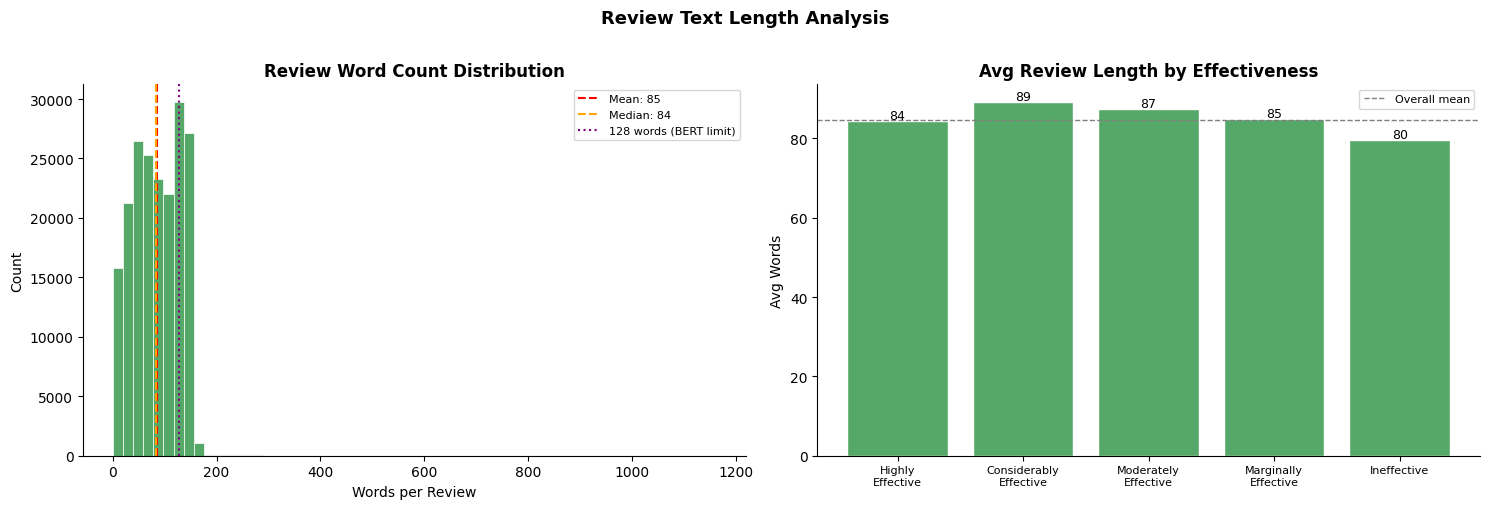

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: word count distribution
axes[0].hist(df['review_len'], bins=60, color='#55A868', edgecolor='white', linewidth=0.5)
axes[0].axvline(df['review_len'].mean(), color='red', linestyle='--', label=f'Mean: {df["review_len"].mean():.0f}')
axes[0].axvline(df['review_len'].median(), color='orange', linestyle='--', label=f'Median: {df["review_len"].median():.0f}')
axes[0].axvline(128, color='purple', linestyle=':', label='128 words (BERT limit)')
axes[0].set_title('Review Word Count Distribution', fontweight='bold')
axes[0].set_xlabel('Words per Review')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=8)
axes[0].spines[['top','right']].set_visible(False)

# Right: avg length by effectiveness
eff_order = ['Highly Effective','Considerably Effective','Moderately Effective',
             'Marginally Effective','Ineffective']
avg_len = df.groupby('effectiveness')['review_len'].mean().reindex(eff_order)
axes[1].bar(range(len(eff_order)), avg_len.values, color='#55A868', edgecolor='white')
axes[1].set_xticks(range(len(eff_order)))
axes[1].set_xticklabels([e.replace(' ', '\n') for e in eff_order], fontsize=8)
axes[1].set_title('Avg Review Length by Effectiveness', fontweight='bold')
axes[1].set_ylabel('Avg Words')
axes[1].axhline(df['review_len'].mean(), color='gray', linestyle='--', linewidth=1, label='Overall mean')
axes[1].legend(fontsize=8)
axes[1].spines[['top','right']].set_visible(False)
for i, v in enumerate(avg_len.values):
    axes[1].text(i, v + 0.5, f'{v:.0f}', ha='center', fontsize=9)

plt.suptitle('Review Text Length Analysis', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### Observations

- Mean: 85 words, Median: 84 words — the distribution is surprisingly symmetric and tight.
- ~75% of reviews fit within 128 tokens — good news for BERT-style models with standard 128-token context.
- Virtually all reviews (>99%) fit within 512 words — no truncation needed for transformer models.
- Longer reviews ≠ more positive: 'Considerably Effective' reviews are actually the longest (avg 90 words), while 'Highly Effective' and 'Ineffective' are shorter — patients who feel ambivalent seem to write more.


---
## 8. Lexical Analysis: Top Words by Sentiment

Examine most frequent content words in positive (rating ≥ 8) vs negative (rating ≤ 3) reviews to get a sense of the signal the text carries.


In [26]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def top_words(texts, n=20):
    words = []
    for t in texts:
        if pd.isnull(t): continue
        words += [w for w in re.findall(r"[a-z']+", t.lower())
                  if w not in ENGLISH_STOP_WORDS and len(w) > 3]
    return Counter(words).most_common(n)

pos_words = top_words(df[df['rating'] >= 8]['benefitsReview'])
neg_words = top_words(df[df['rating'] <= 3]['benefitsReview'])

print('Top 15 words — POSITIVE reviews (rating ≥ 8):')
for w, c in pos_words[:15]: print(f'  {w:<20}: {c:,}')
print()
print('Top 15 words — NEGATIVE reviews (rating ≤ 3):')
for w, c in neg_words[:15]: print(f'  {w:<20}: {c:,}')


Top 15 words — POSITIVE reviews (rating ≥ 8):
  years               : 40,812
  taking              : 35,149
  effects             : 34,749
  pain                : 32,710
  i've                : 32,548
  started             : 28,997
  like                : 28,758
  just                : 28,402
  days                : 28,107
  months              : 28,003
  time                : 27,461
  feel                : 26,586
  life                : 23,651
  it's                : 21,187
  weeks               : 20,745

Top 15 words — NEGATIVE reviews (rating ≤ 3):
  taking              : 13,395
  pain                : 12,011
  months              : 11,983
  like                : 11,831
  started             : 11,015
  i've                : 11,003
  days                : 10,896
  just                : 9,922
  time                : 9,543
  pill                : 9,282
  effects             : 9,244
  took                : 9,210
  weeks               : 8,123
  feel                : 7,860
  doctor       

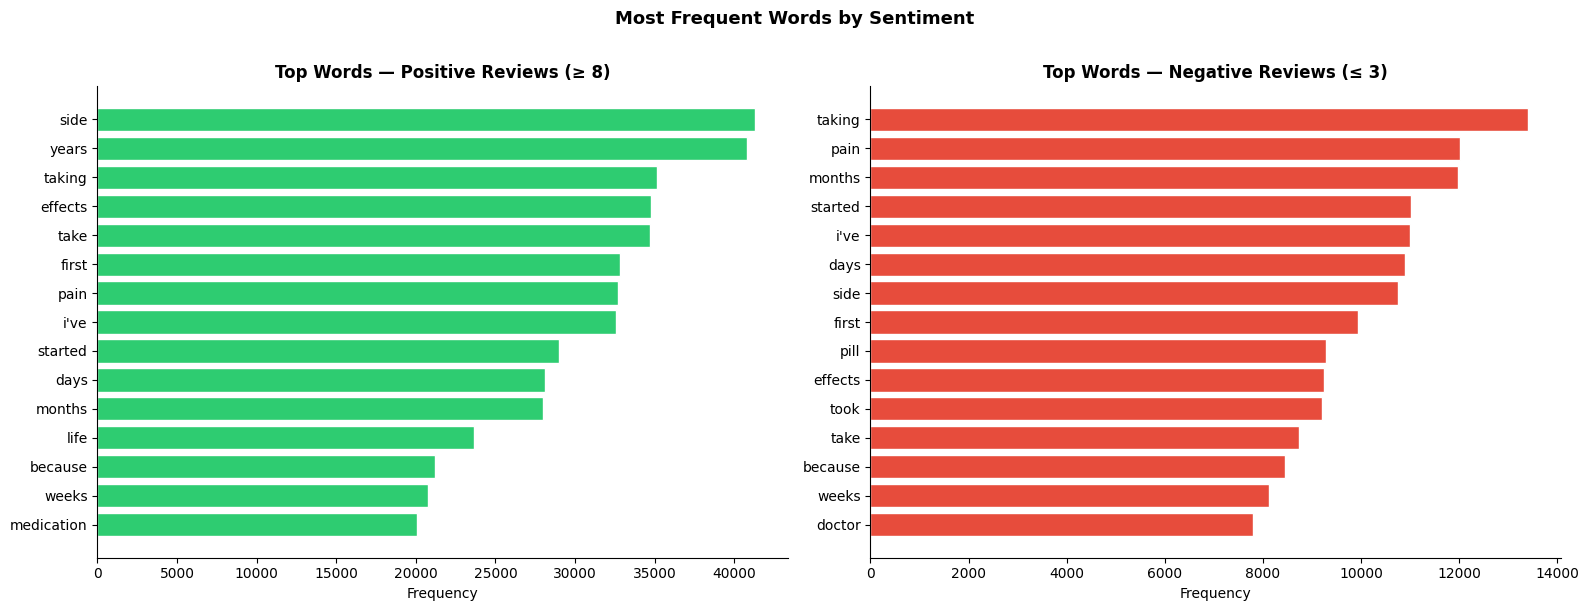

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Positive
pw, pc = zip(*pos_words[:15])
axes[0].barh(list(pw)[::-1], list(pc)[::-1], color='#2ecc71', edgecolor='white')
axes[0].set_title('Top Words — Positive Reviews (≥ 8)', fontweight='bold')
axes[0].set_xlabel('Frequency')
axes[0].spines[['top','right']].set_visible(False)

# Negative
nw, nc = zip(*neg_words[:15])
axes[1].barh(list(nw)[::-1], list(nc)[::-1], color='#e74c3c', edgecolor='white')
axes[1].set_title('Top Words — Negative Reviews (≤ 3)', fontweight='bold')
axes[1].set_xlabel('Frequency')
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('Most Frequent Words by Sentiment', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### Observations

- Positive reviews feature time-based words (`years`, `months`, `days`) suggesting long-term satisfaction, plus domain words (`pain`, `life`, `side effects`) used in a positive framing.
- Negative reviews feature `pill`, `never`, `took`, `because` — suggesting explanation of failure and referencing the physical form of medication.
- High overlap in top words (`pain`, `side`, `effects`, `taking`, `months`) — raw frequency alone won't distinguish classes well. Contextual embeddings (BERT) are needed to capture the *framing* of these shared words.
- `never` appears prominently only in negative reviews — a strong negative signal worth tracking.


---
## 9. Summary & Conclusions

Final summary of findings and recommendations for modeling.


In [24]:
print('=' * 65)
print('EDA SUMMARY')
print('=' * 65)
print(f'Total reviews         : {len(df):,}')
print(f'Unique drugs          : {df["urlDrugName"].nunique():,}')
print(f'Unique conditions     : {df["condition"].nunique():,}')
print(f'Avg review length     : {df["review_len"].mean():.0f} words')
print(f'Reviews < 128 words   : {(df["review_len"] < 128).mean()*100:.1f}%')
print(f'High ratings (≥8)     : {(df["rating"] >= 8).mean()*100:.1f}%')
print(f'Unusable columns      : sideEffectsReview, commentsReview, sideEffects')
print()
print('Key issues to address before modeling:')
issues = [
    '1. Drop sideEffectsReview, commentsReview (100% null), sideEffects (zero variance)',
    '2. Class imbalance: 60% high / 18% low — use stratified splits & weighted loss',
    '3. Condition bias: Birth Control = 18% of data — stratify by condition',
    '4. Rating skew: if using as regression target, consider log-transform or clipping',
    '5. Drug long tail: 3569 drugs, many with 1 review — do not use drug name as feature',
]
for issue in issues:
    print(f'  {issue}')


EDA SUMMARY
Total reviews         : 192,482
Unique drugs          : 3,569
Unique conditions     : 905
Avg review length     : 85 words
Reviews < 128 words   : 76.3%
High ratings (≥8)     : 60.4%
Unusable columns      : sideEffectsReview, commentsReview, sideEffects

Key issues to address before modeling:
  1. Drop sideEffectsReview, commentsReview (100% null), sideEffects (zero variance)
  2. Class imbalance: 60% high / 18% low — use stratified splits & weighted loss
  3. Condition bias: Birth Control = 18% of data — stratify by condition
  4. Rating skew: if using as regression target, consider log-transform or clipping
  5. Drug long tail: 3569 drugs, many with 1 review — do not use drug name as feature


### EDA Conclusions

**Dataset:** 192482 patient drug reviews, 9 columns. Only `benefitsReview` contains usable free text.

**Critical data issues found:**
1. `sideEffectsReview` and `commentsReview` are 100% empty — drop them.
2. `sideEffects` is constant (`'Not Reported'`) — drop it.
3. Ratings are heavily skewed toward 10 — consider binary classification (positive/negative).

**Key patterns found:**
- Birth Control dominates (18%), creating a condition-level imbalance.
- `rating` and `effectiveness` are well-aligned — either can serve as the label.
- Reviews are short and consistent (~85 words avg) — BERT with 128-token context works for ~75% of data.
- Positive/negative classes share many surface words; contextual embeddings will outperform bag-of-words.

**next steps:**
1. Binary label: rating ≥ 7 → positive, rating ≤ 3 → negative (drop mid-range or treat as 3-class)
2. Baseline: Contextual embedding + logistic regression models
3. Strong model: fine-tune maybe try using BERT on `benefitsReview`
4. Stratify train and test splits by `condition` to avoid condition leakage
